In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("csv/iris.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

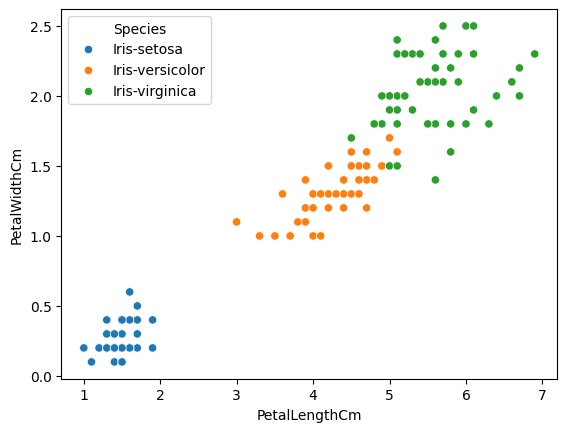

In [5]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue=df["Species"])
plt.show()

In [6]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
df = df.drop("Id", axis=1)

In [8]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]].values
y = df["Species"].values

In [9]:
y

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [11]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [14]:
from torch import nn

class IrisClassifier(nn.Module):
  def __init__(self):
      super().__init__()
      self.linear_layer_stack = nn.Sequential(
          nn.Linear(4, 16),
          nn.ReLU(),
          nn.Linear(16, 16),
          nn.ReLU(),
          nn.Linear(16, 3)
      )

  def forward(self, x):
      return self.linear_layer_stack(x)

In [15]:
torch.manual_seed(42)
model = IrisClassifier()

In [16]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [17]:
from torchmetrics.classification import MulticlassAccuracy

accuracy = MulticlassAccuracy(num_classes=3)

In [18]:
epochs = 200

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
  model.train()

  logits = model(X_train)
  loss = loss_fn(logits, y_train)

  pred = torch.softmax(logits, dim=1).argmax(dim=1)
  acc = accuracy(pred, y_train).item() * 100

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  train_losses.append(loss.item())
  train_accuracies.append(acc)
  
  model.eval()
  with torch.inference_mode():
      test_logits = model(X_test)
      test_loss = loss_fn(test_logits, y_test)

      test_pred = torch.argmax(test_logits, dim=1)
      test_acc = accuracy(test_pred, y_test).item() * 100

  test_losses.append(test_loss.item())
  test_accuracies.append(test_acc)

  if epoch % 20 == 0:
      print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.1047 | Acc: 33.33% | Test Loss: 1.0137 | Test Acc: 66.67%
Epoch 20 | Loss: 0.4823 | Acc: 66.67% | Test Loss: 0.4638 | Test Acc: 70.00%
Epoch 40 | Loss: 0.1671 | Acc: 97.50% | Test Loss: 0.1665 | Test Acc: 100.00%
Epoch 60 | Loss: 0.0663 | Acc: 97.50% | Test Loss: 0.0614 | Test Acc: 100.00%
Epoch 80 | Loss: 0.0570 | Acc: 98.33% | Test Loss: 0.0456 | Test Acc: 100.00%
Epoch 100 | Loss: 0.0537 | Acc: 98.33% | Test Loss: 0.0437 | Test Acc: 100.00%
Epoch 120 | Loss: 0.0516 | Acc: 98.33% | Test Loss: 0.0434 | Test Acc: 100.00%
Epoch 140 | Loss: 0.0497 | Acc: 98.33% | Test Loss: 0.0434 | Test Acc: 100.00%
Epoch 160 | Loss: 0.0481 | Acc: 98.33% | Test Loss: 0.0441 | Test Acc: 100.00%
Epoch 180 | Loss: 0.0468 | Acc: 98.33% | Test Loss: 0.0406 | Test Acc: 100.00%


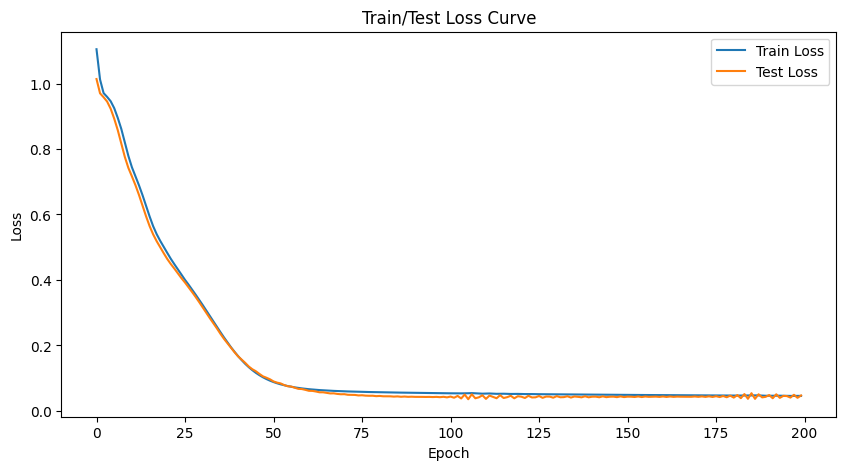

In [19]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss Curve")
plt.legend()
plt.show()

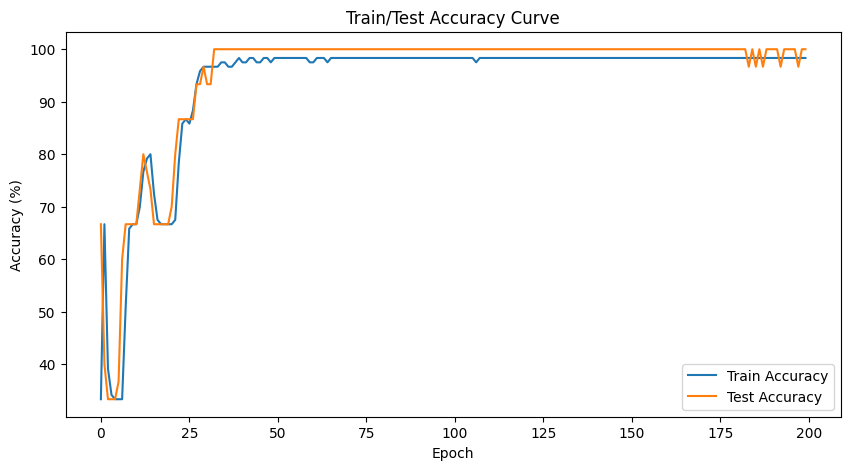

In [20]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train/Test Accuracy Curve")
plt.legend()
plt.show()

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

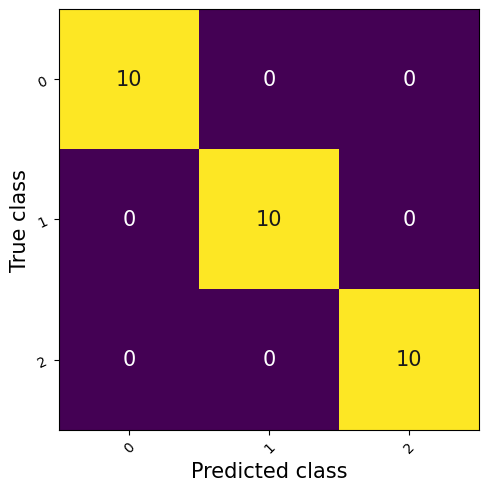

In [21]:
from torchmetrics.classification import MulticlassConfusionMatrix
from torchmetrics.utilities.plot import plot_confusion_matrix

cm = MulticlassConfusionMatrix(num_classes=3)
matrix = cm(test_pred, y_test)

plot_confusion_matrix(matrix)